In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data Processing Pipeline

Data processing pipeline before biomarker discovery.

**Steps**
1. m/z > 500 (mass range)
2. Detection >= 70 % in >= 1 biological class (raw data)
3. Data transformation (we will compare raw/log-transform/total intensity normalisation + log)
4. QC CV < 30 % and D-ratio < 100 % (on TI-normalised log) (TI=Total Intensity)
5. Feature-level run-order drift exclusion R2 >= 0.5 (TI-norm log)
6. Sample outlier detection (IQR + PCA on retained normalised features)
7. Export to `data/preprocessed_data/`

In [61]:
data_matrix = pd.read_csv('data/input/internship_data_matrix.csv',      index_col=0)
features    = pd.read_csv('data/input/internship_feature_metadata.csv', index_col=0)
acquisition = pd.read_csv('data/input/intership_acquisition_list.csv',  index_col=0)

print(f"Data matrix : {data_matrix.shape[0]} samples x {data_matrix.shape[1]} features")
print(f"Classes     : {acquisition['class'].value_counts().to_dict()}")
print(f"Batches     : {acquisition['batch'].value_counts().to_dict()}")

Data matrix : 124 samples x 252 features
Classes     : {'Dunn': 27, 'French': 26, 'LMU': 26, 'QC': 22, 'B': 11, 'dQC': 10, 'SS': 2}
Batches     : {1: 102, 2: 22}


## Sample Scope

Batch 2 has no biological samples, all three cohorts (Dunn, French, LMU) are in Batch 1 only.
We restrict to Batch 1 as suggested in the README file. QC samples serve as the technical reference throughout feature filtering.
Blanks and SS samples are excluded.

As established in the EDA, we will use the 5th percentile on non-zero peak areas as a detection threshold

In [ ]:
acq = acquisition.loc[data_matrix.index]

b1_mask  = acq['batch'] == 1
qc_mask  = b1_mask & (acq['class'] == 'QC')
bio_mask = b1_mask & acq['class'].isin(['Dunn', 'French', 'LMU'])

class_masks = {cls: b1_mask & (acq['class'] == cls) for cls in ['Dunn', 'French', 'LMU']}
# Define a color palette for the classes for later plots
COLORS = {'QC': '#AAAAAA', 'Dunn': '#4C72B0', 'French': '#DD8452', 'LMU': '#55A868'}

# Detection threshold: 5th percentile of non-zero raw values (established in EDA)
nonzero_vals     = data_matrix.values[data_matrix.values > 0]
detection_thresh = float(np.quantile(nonzero_vals, 0.05))

print(f"Detection threshold : {detection_thresh:.2f}")
print(f"Batch 1 -- QC: {qc_mask.sum()}, "
      f"Bio: {bio_mask.sum()} "
      f"(Dunn {class_masks['Dunn'].sum()}, "
      f"French {class_masks['French'].sum()}, "
      f"LMU {class_masks['LMU'].sum()})")

Detection threshold : 31.99
Batch 1 -- QC: 11, Bio: 79 (Dunn 27, French 26, LMU 26)


## Filter 1 : Mass Range (m/z > 500)

Glycans have > 500 m/z, so we select the features corresponding to this mass range.

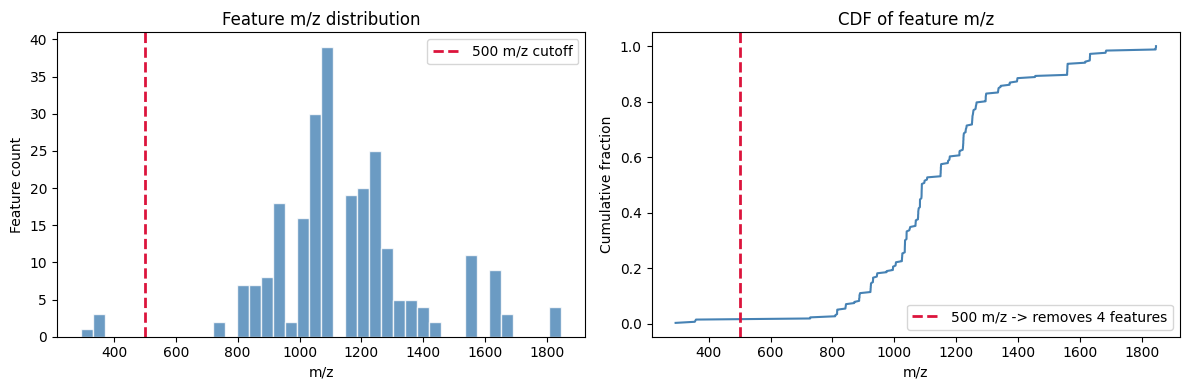

Before : 252  |  Removed : 4  |  Retained : 248
Removed: [359.1, 357.1, 355.1, 293.2]


In [ ]:
mz_pass  = features['mz'] > 500
n_start  = len(features)
n_mz     = mz_pass.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(features['mz'], bins=40, color='blue', edgecolor='white', alpha=0.8)
ax.axvline(500, color='red', lw=2, ls='--', label='500 m/z cutoff')
ax.set_xlabel('m/z'); ax.set_ylabel('Feature count')
ax.set_title('Feature m/z distribution'); ax.legend()

ax = axes[1]
sorted_mz = np.sort(features['mz'].values)
cdf = np.arange(1, len(sorted_mz) + 1) / len(sorted_mz)
ax.plot(sorted_mz, cdf, color='blue')
n_below = (~mz_pass).sum()
ax.axvline(500, color='red', lw=2, ls='--', label=f'500 m/z -> removes {n_below} features')
ax.set_xlabel('m/z'); ax.set_ylabel('Cumulative fraction')
ax.set_title('CDF of feature m/z'); ax.legend()

plt.tight_layout(); plt.show()
print(f"Before : {n_start}  |  Removed : {(~mz_pass).sum()}  |  Retained : {n_mz}")
print(f"Removed: {features.loc[~mz_pass, 'mz'].round(1).tolist()}")

## Filter 2 : Detection Rate >= 70 % (raw data)

A feature must be consistently detected in at least one biological class to be a credible
marker candidate. We will use the 70% detection rate threshold as suggested in the README file.

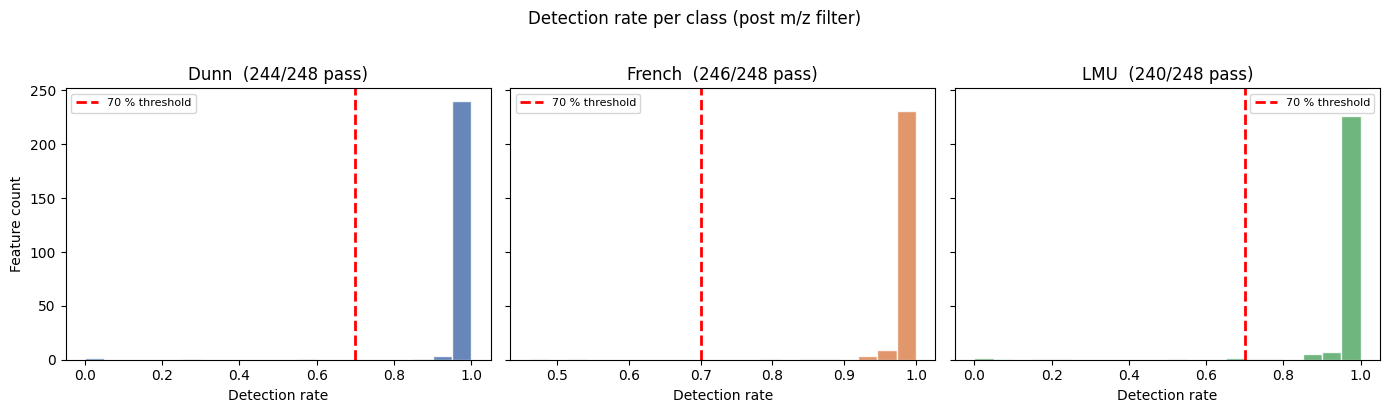

After m/z filter : 248  |  Removed : 1  |  Retained : 247


In [65]:
is_detected  = data_matrix >= detection_thresh
det_by_class = {cls: is_detected.loc[mask].mean() for cls, mask in class_masks.items()}
det_df       = pd.DataFrame(det_by_class)

det_pass = (det_df >= 0.70).any(axis=1)
f2_pass  = mz_pass & det_pass
n_det    = f2_pass.sum()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, cls in zip(axes, ['Dunn', 'French', 'LMU']):
    vals   = det_df[cls][mz_pass]
    n_pass = (vals >= 0.70).sum()
    ax.hist(vals, bins=20, color=COLORS[cls], edgecolor='white', alpha=0.85)
    ax.axvline(0.70, color='red', lw=2, ls='--', label='70 % threshold')
    ax.set_title(f'{cls}  ({n_pass}/{len(vals)} pass)')
    ax.set_xlabel('Detection rate'); ax.legend(fontsize=8)
axes[0].set_ylabel('Feature count')
plt.suptitle('Detection rate per class (post m/z filter)', y=1.02)
plt.tight_layout(); plt.show()

print(f"After m/z filter : {n_mz}  |  Removed : {(mz_pass & ~det_pass).sum()}  |  Retained : {n_det}")

## Transformation Comparison
As seen in the EDA, although we have low QC CV, meaning low technical variability, however it still dominates biological variability (high D-ratio), therefore we need to apply data transformations.

Two transformations are compared on features along with raw data, passing filters 1-2.

| Approach | Description and Justification |
|----------|-------------|
| **Raw** | Original peak areas: Baseline |
| **Log (log1p)** | Apply log(1+x): Reduces skewness and effect of large peaks, so stabilize variance |
| **TI-normalised log** | Each sample divided by its total intensity and multiplied by the median total intensity then log1p: removes global intensity differences between samples and keeps scale comparable (thanks to median) and stabilize variance with log1p |

We evaluate:
- **PCA plot** : QC samples should cluster tightly; cohorts should show biological structure
- **QC CV** = std(QC) / mean(QC) x 100 : technical reproducibility per feature; lower is better
- **D-ratio** = sqrt(var_QC / var_bio) x 100 : technical vs biological variance; <100 % means biology dominates

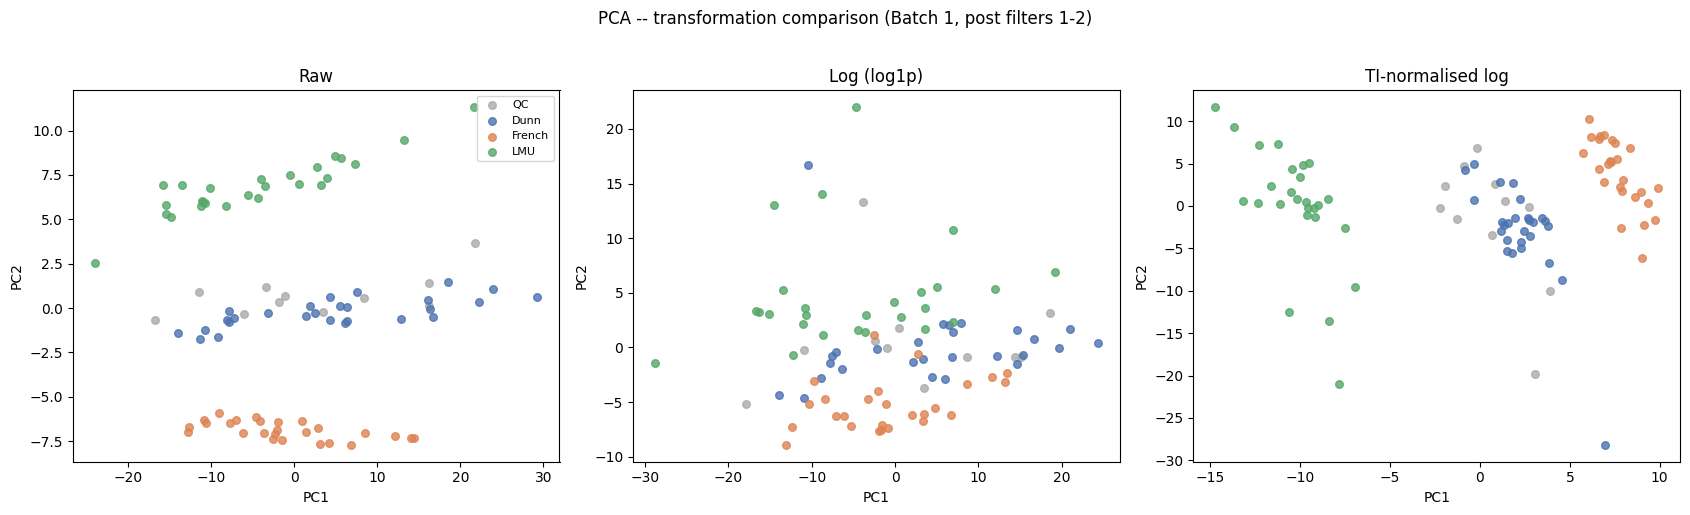

Transformation                QC CV median    QC CV >30%    D-ratio median   D-ratio <100%
------------------------------------------------------------------------------------------
  Raw                              19.79 %          57           103.0 %           116 / 247
  Log (log1p)                       2.92 %           9            96.3 %           135 / 247
  TI-normalised log                 2.00 %           9            84.6 %           153 / 247


In [82]:
b1_all_idx = acq[b1_mask & acq['class'].isin(['Dunn', 'French', 'LMU', 'QC'])].index
acq_b1     = acq.loc[b1_all_idx]
X_b1_raw   = data_matrix.loc[b1_all_idx, features.index[f2_pass]]

qc_b1_idx  = acq_b1[acq_b1['class'] == 'QC'].index
bio_b1_idx = acq_b1[acq_b1['class'].isin(['Dunn', 'French', 'LMU'])].index

def ti_norm(df):
    ti = df.sum(axis=1)
    return df.div(ti, axis=0) * ti.median()

transforms = {
    'Raw':               X_b1_raw,
    'Log (log1p)':       np.log1p(X_b1_raw),
    'TI-normalised log': np.log1p(ti_norm(X_b1_raw)),
}

class_order = ['QC', 'Dunn', 'French', 'LMU']

# PCA plots
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (label, Xt) in zip(axes, transforms.items()):
    Xc = Xt.replace([np.inf, -np.inf], np.nan).fillna(0)
    pc = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(Xc))
    for cls in class_order:
        mask = acq_b1['class'] == cls
        ax.scatter(pc[mask, 0], pc[mask, 1], label=cls,
                   color=COLORS[cls], s=30, alpha=0.8)
    ax.set_title(label); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
axes[0].legend(fontsize=8)
plt.suptitle('PCA -- transformation comparison (Batch 1, post filters 1-2)', y=1.02)
plt.tight_layout(); plt.show()

# CV + D-ratio table
header = f"{'Transformation':<26}  {'QC CV median':>14}  {'QC CV >30%':>12}  {'D-ratio median':>16}  {'D-ratio <100%':>14}"
print(header)
print('-' * 90)
for label, Xt in transforms.items():
    Xc      = Xt.replace([np.inf, -np.inf], np.nan).fillna(0)
    qc_v    = Xc.loc[qc_b1_idx]
    bio_v   = Xc.loc[bio_b1_idx]
    cv      = 100 * qc_v.std(ddof=1) / qc_v.mean().replace(0, np.nan)
    d_ratio = 100 * np.sqrt(qc_v.var(ddof=1) / bio_v.var(ddof=1).replace(0, np.nan))
    row = (f"  {label:<24}  {cv.median():>12.2f} %  {(cv > 30).sum():>10}  "
           f"{d_ratio.median():>14.1f} %  {(d_ratio < 100).sum():>12} / {len(d_ratio)}")
    print(row)

We can clearly see that TI-normalisation + log1p gives up the lowest QC CV and D-ratio (lowest median and highest number of features that falls under our thresholds)

## Filters 3 & 4 : QC CV < 30 % and D-ratio < 100 % (TI-normalised log)

- **QC CV**: features with > 30 % QC CV have high technical variability (technical/instrument noise)
- **D-ratio**: features with D-ratio >= 100 % have technical variance exceeding biological variance, any apparent class difference is untrustworthy

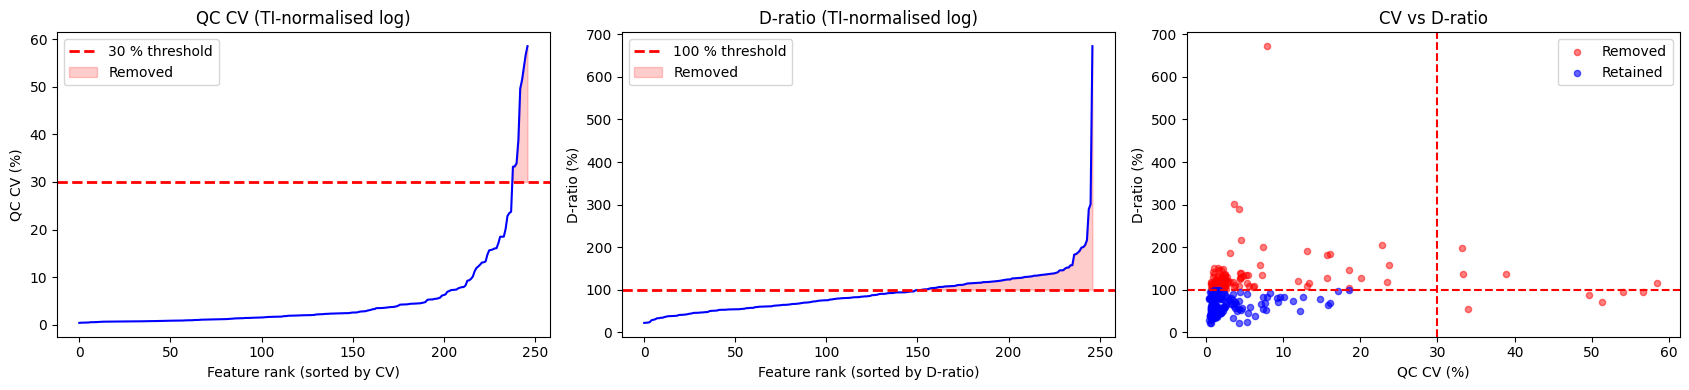

After detection filter    : 247
QC CV >= 30 % removed     : 9
D-ratio >= 100 % removed  : 90
Retained after F3 + F4    : 148


In [83]:
X_norm = np.log1p(ti_norm(X_b1_raw))   # TI-norm log, all b1 bio+QC, post-filter-2 features

qc_v   = X_norm.loc[qc_b1_idx]
bio_v  = X_norm.loc[bio_b1_idx]

qc_cv   = 100 * qc_v.std(ddof=1) / qc_v.mean().replace(0, np.nan)
d_ratio = 100 * np.sqrt(qc_v.var(ddof=1) / bio_v.var(ddof=1).replace(0, np.nan))

cv_pass     = qc_cv < 30
dratio_pass = d_ratio < 100
f34_pass    = cv_pass & dratio_pass

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# CV ranked plot
ax = axes[0]
sorted_cv = np.sort(qc_cv.values)
ax.plot(sorted_cv, color='blue', lw=1.5)
ax.axhline(30, color='red', lw=2, ls='--', label='30 % threshold')
ax.fill_between(range(len(sorted_cv)), sorted_cv, 30,
                where=(sorted_cv >= 30), color='red', alpha=0.2, label='Removed')
ax.set_xlabel('Feature rank (sorted by CV)'); ax.set_ylabel('QC CV (%)')
ax.set_title('QC CV (TI-normalised log)'); ax.legend()

# D-ratio ranked plot
ax = axes[1]
sorted_dr = np.sort(d_ratio.values)
ax.plot(sorted_dr, color='blue', lw=1.5)
ax.axhline(100, color='red', lw=2, ls='--', label='100 % threshold')
ax.fill_between(range(len(sorted_dr)), sorted_dr, 100,
                where=(sorted_dr >= 100), color='red', alpha=0.2, label='Removed')
ax.set_xlabel('Feature rank (sorted by D-ratio)'); ax.set_ylabel('D-ratio (%)')
ax.set_title('D-ratio (TI-normalised log)'); ax.legend()

# Joint scatter
ax = axes[2]
ax.scatter(qc_cv[~f34_pass], d_ratio[~f34_pass],
           color='red', s=20, alpha=0.5, label='Removed')
ax.scatter(qc_cv[f34_pass], d_ratio[f34_pass],
           color='blue', s=20, alpha=0.6, label='Retained')
ax.axvline(30,  color='red', ls='--', lw=1.5)
ax.axhline(100, color='red', ls='--', lw=1.5)
ax.set_xlabel('QC CV (%)'); ax.set_ylabel('D-ratio (%)')
ax.set_title('CV vs D-ratio'); ax.legend()

plt.tight_layout(); plt.show()

n_f34 = f34_pass.sum()
print(f"After detection filter    : {f2_pass.sum()}")
print(f"QC CV >= 30 % removed     : {(~cv_pass).sum()}")
print(f"D-ratio >= 100 % removed  : {(cv_pass & ~dratio_pass).sum()}")
print(f"Retained after F3 + F4    : {n_f34}")

## Filter 5 : Run-order Drift (TI-normalised log, R2 < 0.5)

A linear regression of QC intensity vs. acquisition order is fitted per feature on the
TI-normalised log data. R2 >= 0.5 means >50 % of the QC variance is explained by run
position meaning a feature-specific drift that TI normalisation did not correct.

These features are dangerous for biomarker discovery: cohort samples are not evenly spread across the run, so instrument drift creates artificial class differences that are
indistinguishable from true biological signal.

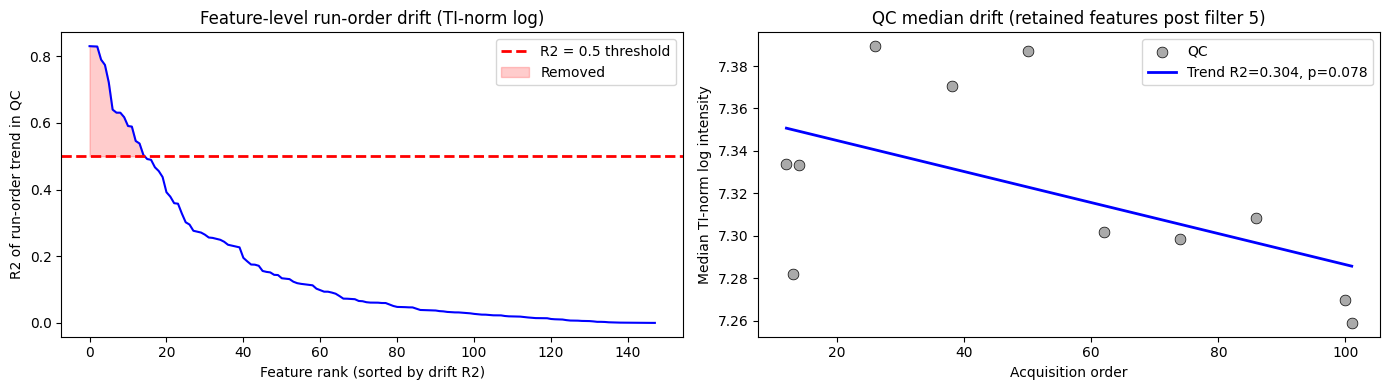

Entering drift filter        : 148
Strong drift removed (R2>=0.5): 15
Retained after all filters   : 133
  Removed: {'FT-123': 0.831, 'FT-152': 0.83, 'FT-244': 0.829, 'FT-127': 0.79, 'FT-240': 0.774, 'FT-204': 0.722, 'FT-238': 0.64, 'FT-206': 0.631, 'FT-133': 0.631, 'FT-153': 0.617, 'FT-245': 0.591, 'FT-159': 0.589, 'FT-235': 0.546, 'FT-243': 0.538, 'FT-208': 0.504}


In [84]:
feat_f4   = features.index[f2_pass & f34_pass].tolist()
qc_order  = acq_b1.loc[qc_b1_idx, 'order'].sort_values()
X_qc_norm = X_norm.loc[qc_order.index, feat_f4]
order_v   = qc_order.values.astype(float)

drift_r2 = {}
for feat in feat_f4:
    y = X_qc_norm[feat].values
    if y.std() > 0:
        _, _, r, _, _ = stats.linregress(order_v, y)
        drift_r2[feat] = r ** 2
    else:
        drift_r2[feat] = 0.0

drift_r2_s = pd.Series(drift_r2).sort_values(ascending=False)
drift_pass = drift_r2_s < 0.5
feat_final = drift_pass[drift_pass].index.tolist()
n_drift_rm = (~drift_pass).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(drift_r2_s.values, color='blue', lw=1.5)
ax.axhline(0.5, color='red', ls='--', lw=2, label='R2 = 0.5 threshold')
ax.fill_between(range(len(drift_r2_s)), drift_r2_s.values, 0.5,
                where=(drift_r2_s.values >= 0.5),
                color='red', alpha=0.2, label='Removed')
ax.set_xlabel('Feature rank (sorted by drift R2)')
ax.set_ylabel('R2 of run-order trend in QC')
ax.set_title('Feature-level run-order drift (TI-norm log)'); ax.legend()

ax = axes[1]
qc_med = X_norm.loc[qc_order.index, feat_final].median(axis=1)
sl, ic, r, p, _ = stats.linregress(order_v, qc_med.values)
ax.scatter(order_v, qc_med.values, color='#AAAAAA', s=60,
           edgecolors='black', lw=0.5, zorder=3, label='QC')
trend_x = np.array([order_v.min(), order_v.max()])
ax.plot(trend_x, ic + sl * trend_x, color='blue', lw=2,
        label=f'Trend R2={r**2:.3f}, p={p:.3f}')
ax.set_xlabel('Acquisition order')
ax.set_ylabel('Median TI-norm log intensity')
ax.set_title('QC median drift (retained features post filter 5)'); ax.legend()

plt.tight_layout(); plt.show()

print(f"Entering drift filter        : {len(feat_f4)}")
print(f"Strong drift removed (R2>=0.5): {n_drift_rm}")
print(f"Retained after all filters   : {len(feat_final)}")
if n_drift_rm > 0:
    print('  Removed:', drift_r2_s[~drift_pass].round(3).to_dict())

Let's check for each filter how many features we removed

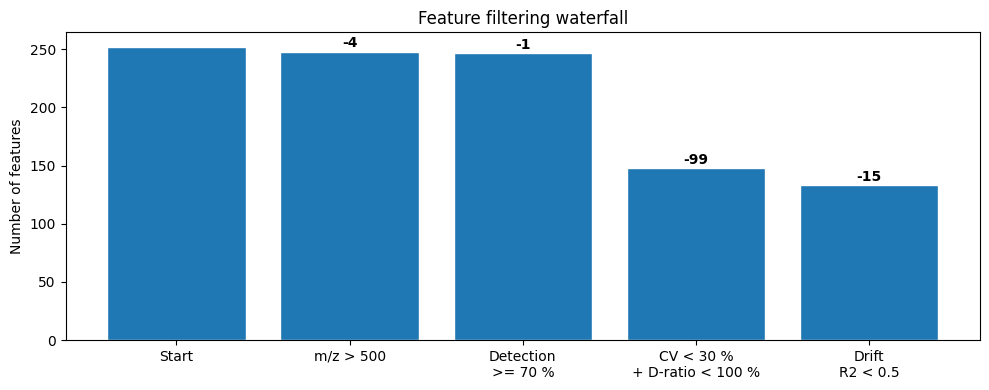

In [85]:
steps  = ['Start', 'm/z > 500', 'Detection\n>= 70 %',
          'CV < 30 %\n+ D-ratio < 100 %', 'Drift\nR2 < 0.5']
counts = [n_start, n_mz, n_det, n_f34, len(feat_final)]
removed = [0] + [counts[i-1] - counts[i] for i in range(1, len(counts))]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(steps, counts, edgecolor='white')
for bar, r in zip(bars[1:], removed[1:]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1, f'-{r}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_ylabel('Number of features')
ax.set_title('Feature filtering waterfall')
plt.tight_layout(); plt.show()

## Sample Outlier Detection

Performed on the TI-normalised log matrix restricted to the final feature set.
Two complementary criteria flag outliers:
- **IQR on summed intensity** : outliers that lie far from the 25th and 75th quantiles on summed log intensity.
- **PCA distance (3 sigma)** : outliers that are too far from their corresponding class centroid in PCA space, this captures profile-level anomalies that total intensity alone would miss

A sample flagged by either criterion is reviewed for exclusion.

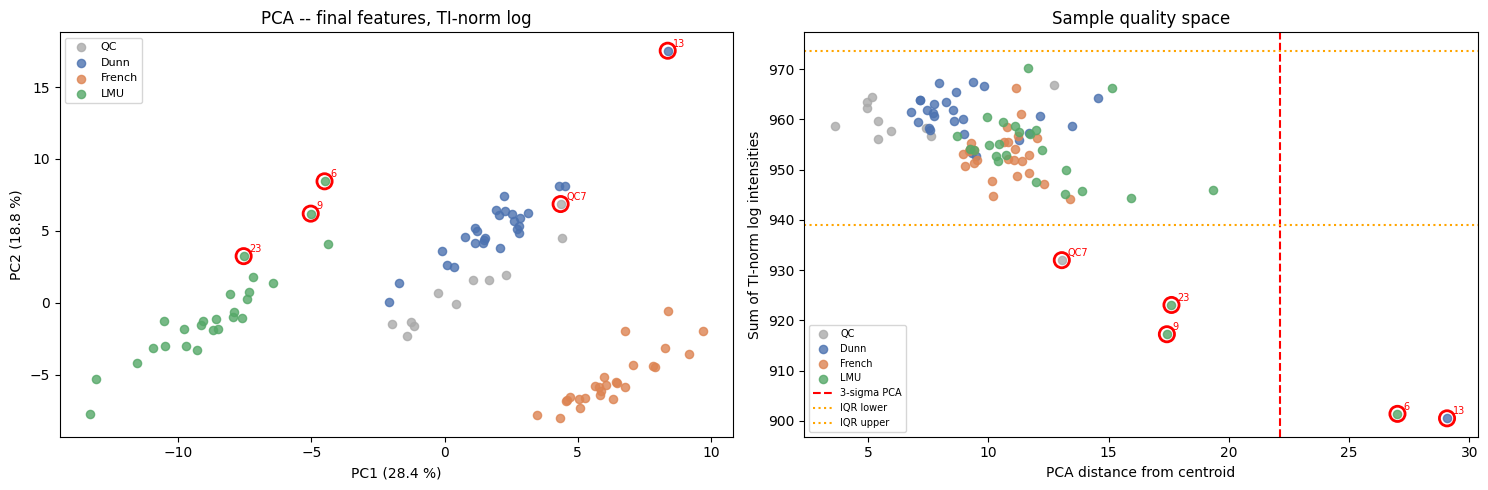

IQR outliers (intensity) : ['20241106-297-Dunn-13', '20241106-297-LMU-23', '20241106-297-LMU-6', '20241106-297-LMU-9', '20241106-297-QC7']
PCA outliers (3-sigma)   : ['20241106-297-Dunn-13', '20241106-297-LMU-6']
Combined to exclude      : ['20241106-297-LMU-23', '20241106-297-LMU-6', '20241106-297-LMU-9', '20241106-297-QC7', '20241106-297-Dunn-13']


In [86]:
X_norm_final = X_norm[feat_final]   # TI-norm log, b1 bio+QC, final features

# IQR on summed TI-norm log intensity
log_total = X_norm_final.sum(axis=1)
Q1, Q3    = log_total.quantile(0.25), log_total.quantile(0.75)
IQR       = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
iqr_out   = log_total[(log_total < lower) | (log_total > upper)].index.tolist()

# PCA distance from centroid
Xc       = X_norm_final.fillna(0)
Xs       = StandardScaler().fit_transform(Xc)
pca_    = PCA(n_components=0.95)
pca      = pca_.fit_transform(Xs)
centroid = pca.mean(axis=0)
dist     = np.sqrt(((pca - centroid) ** 2).sum(axis=1))
dist_s   = pd.Series(dist, index=b1_all_idx)
mu, sd   = dist_s.mean(), dist_s.std()
pca_out  = dist_s[dist_s > mu + 3 * sd].index.tolist()

all_outliers = list(set(iqr_out + pca_out))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for cls in ['QC', 'Dunn', 'French', 'LMU']:
    mask = acq_b1['class'] == cls
    ax.scatter(pca[mask, 0], pca[mask, 1], label=cls,
               color=COLORS[cls], s=35, alpha=0.8)
for s in all_outliers:
    idx = list(b1_all_idx).index(s)
    ax.scatter(pca[idx, 0], pca[idx, 1], s=120,
               facecolors='none', edgecolors='red', lw=2, zorder=5)
    ax.annotate(s.split('-')[-1], (pca[idx, 0], pca[idx, 1]),
                fontsize=7, color='red', xytext=(4, 3),
                textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca_.explained_variance_ratio_[0]*100:.1f} %)')
ax.set_ylabel(f'PC2 ({pca_.explained_variance_ratio_[1]*100:.1f} %)')
ax.set_title('PCA -- final features, TI-norm log'); ax.legend(fontsize=8)

ax = axes[1]
for cls in ['QC', 'Dunn', 'French', 'LMU']:
    mask = acq_b1['class'] == cls
    idxs = [s for s in b1_all_idx[mask.values]]
    ax.scatter(dist_s[idxs], log_total[idxs], label=cls,
               color=COLORS[cls], s=35, alpha=0.8)
for s in all_outliers:
    ax.scatter(dist_s[s], log_total[s], s=120,
               facecolors='none', edgecolors='red', lw=2, zorder=5)
    ax.annotate(s.split('-')[-1], (dist_s[s], log_total[s]),
                fontsize=7, color='red', xytext=(4, 3),
                textcoords='offset points')
ax.axvline(mu + 3 * sd, color='red', ls='--', lw=1.5, label='3-sigma PCA')
ax.axhline(lower, color='orange', ls=':', lw=1.5, label=f'IQR lower')
ax.axhline(upper, color='orange', ls=':', lw=1.5, label=f'IQR upper')
ax.set_xlabel('PCA distance from centroid')
ax.set_ylabel('Sum of TI-norm log intensities')
ax.set_title('Sample quality space'); ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

print(f"IQR outliers (intensity) : {iqr_out}")
print(f"PCA outliers (3-sigma)   : {pca_out}")
print(f"Combined to exclude      : {all_outliers}")

## Final Matrices

Biological samples (Dunn, French, LMU) only, QC samples served their purpose as
technical references and are excluded from the biomarker discovery matrix.

Two files are saved:
- **data_matrix_norm.csv** : TI-normalised log1p; ready for statistical testing and modelling
- **data_matrix_raw.csv** : raw intensities, same feature/sample subset, in case we need raw features.

In [87]:
retained_samples = [s for s in b1_all_idx
                    if acq_b1.loc[s, 'class'] in ['Dunn', 'French', 'LMU']
                    and s not in all_outliers]
retained_acq = acq.loc[retained_samples]

print('Retained samples per class:')
print(retained_acq['class'].value_counts().to_string())
print(f'Total : {len(retained_samples)}')
if all_outliers:
    print('\nExcluded samples:')
    for s in all_outliers:
        reasons = []
        if s in iqr_out: reasons.append('IQR intensity')
        if s in pca_out: reasons.append('PCA 3-sigma')
        print(f'  {s} ({acq.loc[s, "class"]}): {chr(44).join(reasons)}')

X_final_norm = X_norm.loc[retained_samples, feat_final]
X_final_raw  = data_matrix.loc[retained_samples, feat_final]

feat_meta = features.loc[feat_final].copy()
feat_meta['qc_cv_pct']   = qc_cv[feat_final].values
feat_meta['d_ratio_pct'] = d_ratio[feat_final].values
feat_meta['drift_r2']    = pd.Series(drift_r2)[feat_final].values
feat_meta['det_Dunn']    = det_df.loc[feat_final, 'Dunn'].values
feat_meta['det_French']  = det_df.loc[feat_final, 'French'].values
feat_meta['det_LMU']     = det_df.loc[feat_final, 'LMU'].values

print(f'\nFinal matrix : {X_final_norm.shape[0]} samples x {X_final_norm.shape[1]} features')
print(f'm/z range    : {feat_meta["mz"].min():.1f} - {feat_meta["mz"].max():.1f}')

Retained samples per class:
class
Dunn      26
French    26
LMU       23
Total : 75

Excluded samples:
  20241106-297-LMU-23 (LMU): IQR intensity
  20241106-297-LMU-6 (LMU): IQR intensity,PCA 3-sigma
  20241106-297-LMU-9 (LMU): IQR intensity
  20241106-297-QC7 (QC): IQR intensity
  20241106-297-Dunn-13 (Dunn): IQR intensity,PCA 3-sigma

Final matrix : 75 samples x 133 features
m/z range    : 728.0 - 1846.3


Let's visualize our final data on the first two principal components

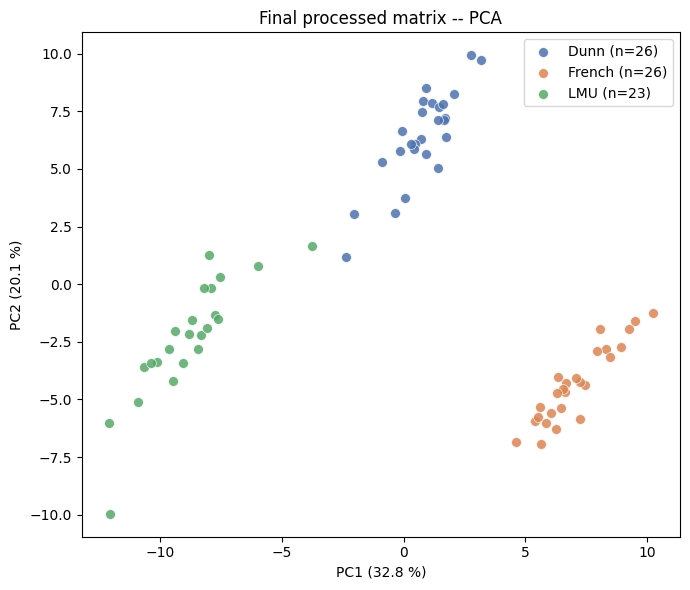

PC1+PC2 variance explained: 52.9 %


In [88]:
Xs_fin  = StandardScaler().fit_transform(X_final_norm.fillna(0))
pca_fin = PCA(n_components=0.95)
pc_fin  = pca_fin.fit_transform(Xs_fin)
ret_acq = retained_acq

fig, ax = plt.subplots(figsize=(7, 6))
for cls in ['Dunn', 'French', 'LMU']:
    mask = ret_acq['class'] == cls
    ax.scatter(pc_fin[mask, 0], pc_fin[mask, 1],
               label=f'{cls} (n={mask.sum()})',
               color=COLORS[cls], s=50, alpha=0.85,
               edgecolors='white', lw=0.5)
ax.set_xlabel(f'PC1 ({pca_fin.explained_variance_ratio_[0]*100:.1f} %)')
ax.set_ylabel(f'PC2 ({pca_fin.explained_variance_ratio_[1]*100:.1f} %)')
ax.set_title('Final processed matrix -- PCA')
ax.legend(); plt.tight_layout(); plt.show()
print(f'PC1+PC2 variance explained: {sum(pca_fin.explained_variance_ratio_[:2])*100:.1f} %')

In [89]:
os.makedirs('data/preprocessed_data', exist_ok=True)

X_final_norm.to_csv('data/preprocessed_data/data_matrix_norm.csv')
X_final_raw.to_csv('data/preprocessed_data/data_matrix_raw.csv')
feat_meta.to_csv('data/preprocessed_data/retained_features.csv')
retained_acq.to_csv('data/preprocessed_data/retained_samples.csv')

print('Saved to data/preprocessed_data/')
print('  data_matrix_norm.csv   -- TI-normalised log1p, ready for statistics')
print('  data_matrix_raw.csv    -- raw intensities, same feature/sample subset')
print('  retained_features.csv  -- feature metadata + QC CV, D-ratio, drift R2, detection rates')
print('  retained_samples.csv   -- sample metadata for retained biological samples')

Saved to data/preprocessed_data/
  data_matrix_norm.csv   -- TI-normalised log1p, ready for statistics
  data_matrix_raw.csv    -- raw intensities, same feature/sample subset
  retained_features.csv  -- feature metadata + QC CV, D-ratio, drift R2, detection rates
  retained_samples.csv   -- sample metadata for retained biological samples
